In [2]:
import pandas as pd

df = pd.read_excel("DF_FINAL.xlsx")

df.head()

calles_base = [
        "Avenida Rafaela Ybarra",
        "Avenida de Oporto",
        "Calle Alcocer",
        "Calle Embajadores",
        "Calle Méndez Álvaro",
        "Calle Ronda de Valencia",
        "Calle Silvano",
        "Calle Toledo",
        "Calle de Gran Vía de San Francisco",
        "Calle de Marcelo Usera",
        "Paseo de Extremadura",
        "Paseo de Santa María de la Cabeza"
]

calles_sur = []

for base in calles_base:
    for col in df.columns:
        if base in col:
            calles_sur.append(col)

L = 3  # número de lags

X = pd.DataFrame()

for street in calles_sur:
    for lag in range(1, L + 1):
        X[f"{street}_t-{lag}"] = df[street].shift(lag)

# Variables externas reales
X["AEMET_tmed"] = df["AEMET_tmed"]
X["AEMET_prec"] = df["AEMET_prec"]
X["dia_semana"] = df["dia_semana"]
X["festivo"] = df["festivo"]

# Convertir variables categóricas a numéricas
X["dia_semana"] = X["dia_semana"].map({
    "lunes": 0,
    "martes": 1,
    "miércoles": 2,
    "jueves": 3,
    "viernes": 4,
    "sábado": 5,
    "domingo": 6
})

X["festivo"] = X["festivo"].map({
    "no": 0,
    "sí": 1
})


y_col = [col for col in df.columns if "Calle Embajadores" in col][0]
y = df[y_col]

# Limpiar NaNs
X = X.dropna()
y = y.loc[X.index]

In [3]:
split = int(len(X) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

In [4]:
X_train

,Avenida Rafaela Ybarra_N-S_t-1,Avenida Rafaela Ybarra_N-S_t-2,Avenida Rafaela Ybarra_N-S_t-3,Avenida Rafaela Ybarra_S-N_t-1,Avenida Rafaela Ybarra_S-N_t-2,Avenida Rafaela Ybarra_S-N_t-3,Avenida de Oporto_O-E_t-1,Avenida de Oporto_O-E_t-2,Avenida de Oporto_O-E_t-3,Calle Alcocer_E-O_t-1,...,Paseo de Santa María de la Cabeza_N-S_t-1,Paseo de Santa María de la Cabeza_N-S_t-2,Paseo de Santa María de la Cabeza_N-S_t-3,Paseo de Santa María de la Cabeza_S-N_t-1,Paseo de Santa María de la Cabeza_S-N_t-2,Paseo de Santa María de la Cabeza_S-N_t-3,AEMET_tmed,AEMET_prec,dia_semana,festivo
3,47.0,52.0,122.0,30.0,45.0,88.0,90.0,128.0,206.0,14.0,...,696.0,659.0,997.0,108.0,134.0,219.0,19.6,0.0,4.0,0.0
4,34.0,47.0,52.0,22.0,30.0,45.0,73.0,90.0,128.0,16.0,...,504.0,696.0,659.0,175.0,108.0,134.0,19.6,0.0,4.0,0.0
5,24.0,34.0,47.0,25.0,22.0,30.0,87.0,73.0,90.0,21.0,...,433.0,504.0,696.0,180.0,175.0,108.0,19.6,0.0,4.0,0.0
6,43.0,24.0,34.0,48.0,25.0,22.0,182.0,87.0,73.0,29.0,...,407.0,433.0,504.0,1086.0,180.0,175.0,19.6,0.0,4.0,0.0
7,92.0,43.0,24.0,138.0,48.0,25.0,454.0,182.0,87.0,97.0,...,765.0,407.0,433.0,1347.0,1086.0,180.0,19.6,0.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25046,307.0,271.0,247.0,224.0,212.0,188.0,447.0,436.0,428.0,238.0,...,2178.0,2038.0,1779.0,1269.0,1265.0,1280.0,32.2,0.0,4.0,0.0
25047,271.0,307.0,271.0,218.0,224.0,212.0,475.0,447.0,436.0,279.0,...,2613.0,2178.0,2038.0,1350.0,1269.0,1265.0,32.2,0.0,4.0,0.0
25048,240.0,271.0,307.0,182.0,218.0,224.0,439.0,475.0,447.0,253.0,...,2475.0,2613.0,2178.0,1205.0,1350.0,1269.0,32.2,0.0,4.0,0.0
25049,277.0,240.0,271.0,193.0,182.0,218.0,412.0,439.0,475.0,183.0,...,2006.0,2475.0,2613.0,1036.0,1205.0,1350.0,32.2,0.0,4.0,0.0


In [5]:
with pd.ExcelWriter("dataset_RF_Embajadores.xlsx") as writer:
    X_train.to_excel(writer, sheet_name="X_train")
    X_test.to_excel(writer, sheet_name="X_test")
    y_train.to_excel(writer, sheet_name="y_train")
    y_test.to_excel(writer, sheet_name="y_test")

In [6]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=10,
    min_samples_leaf=20,
    random_state=0,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=20, n_estimators=400,
                      n_jobs=-1, random_state=0)

In [7]:
# Predicción en test
y_pred = rf.predict(X_test)

# Predicción próxima hora
X_next = X.iloc[[-1]]
y_next = rf.predict(X_next)

print("Predicción tráfico en Embajadores (E-O) próxima hora:", y_next[0])

Predicción tráfico en Embajadores (E-O) próxima hora: 327.39442669479723


In [8]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Cálculo de métricas
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

def mape(y_true, y_pred, eps=1e-6):
    return np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100

mape_val = mape(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape_val:.2f} %")

MAE: 49.93
RMSE: 68.49
MAPE: 10.29 %


In [9]:
importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importances.head(10))

Calle Silvano_E-O_t-1                         0.770336
Paseo de Santa María de la Cabeza_S-N_t-1     0.080166
Calle Méndez Álvaro_S-N_t-1                   0.038954
Calle Embajadores_E-O_t-1                     0.030890
Calle Méndez Álvaro_S-N_t-2                   0.030795
Calle Méndez Álvaro_N-S_t-1                   0.011436
Avenida Rafaela Ybarra_N-S_t-2                0.008525
Calle Silvano_O-E_t-1                         0.004959
Calle Toledo_S-N_t-1                          0.004417
Calle de Gran Vía de San Francisco_S-N_t-1    0.002483
dtype: float64


In [10]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=0,
    n_jobs=-1,
    scoring="neg_mean_absolute_error"
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

perm_df.head(10)


,feature,importance
33,Calle Silvano_E-O_t-1,138.495000
66,Paseo de Santa María de la Cabeza_S-N_t-1,31.485459
15,Calle Embajadores_E-O_t-1,26.047225
24,Calle Méndez Álvaro_S-N_t-1,4.384280
21,Calle Méndez Álvaro_N-S_t-1,1.682709
71,dia_semana,1.200940
1,Avenida Rafaela Ybarra_N-S_t-2,1.130611
48,Calle de Gran Vía de San Francisco_S-N_t-1,0.894387
36,Calle Silvano_O-E_t-1,0.880060
42,Calle Toledo_S-N_t-1,0.763704


In [11]:
top_k = 8
top_features = perm_df.head(top_k)
top_features


,feature,importance
33,Calle Silvano_E-O_t-1,138.495000
66,Paseo de Santa María de la Cabeza_S-N_t-1,31.485459
15,Calle Embajadores_E-O_t-1,26.047225
24,Calle Méndez Álvaro_S-N_t-1,4.384280
21,Calle Méndez Álvaro_N-S_t-1,1.682709
71,dia_semana,1.200940
1,Avenida Rafaela Ybarra_N-S_t-2,1.130611
48,Calle de Gran Vía de San Francisco_S-N_t-1,0.894387


In [12]:
top_streets = (
    top_features["feature"]
    .str.split("_")
    .str[0]
    .value_counts()
)
top_streets

feature
Calle Méndez Álvaro                   2
Paseo de Santa María de la Cabeza     1
Calle Silvano                         1
Calle Embajadores                     1
dia                                   1
Avenida Rafaela Ybarra                1
Calle de Gran Vía de San Francisco    1
Name: count, dtype: int64

In [13]:
from pathlib import Path

# Cambiar estos dos valores en cada notebook
modelo = "RF"
calle = "Calle Embajadores"

# Carpeta donde se guardarán las importancias
output_dir = Path("importancias_variables")
output_dir.mkdir(exist_ok=True)

# Guardar todas las variables, no solo el top 10
perm_df_export = perm_df.copy()
perm_df_export["modelo"] = modelo
perm_df_export["calle"] = calle

# Nombre limpio para el archivo
nombre_archivo = f"{modelo}_{calle}".replace(" ", "_").replace("á", "a").replace("é", "e")
nombre_archivo = nombre_archivo.replace("í", "i").replace("ó", "o").replace("ú", "u")

perm_df_export.to_csv(output_dir / f"{nombre_archivo}.csv", index=False)

print(f"Archivo guardado: {output_dir / f'{nombre_archivo}.csv'}")

Archivo guardado: importancias_variables\RF_Calle_Embajadores.csv


In [14]:
calle_objetivo = "Calle Embajadores"   # cámbialo según el notebook
modelo = "RF"                # opcional, para tenerlo identificado

In [15]:
import pandas as pd
import unicodedata

def normalizar_texto(texto):
    texto = str(texto).lower()
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    return texto

def clasificar_variable(feature, calle_objetivo):
    f = normalizar_texto(feature)
    calle = normalizar_texto(calle_objetivo)

    # Variables meteorológicas
    if any(palabra in f for palabra in [
        'aemet', 'tmed', 'temp', 'temperatura', 'prec', 'precipitacion',
        'humedad', 'viento', 'presion', 'radiacion'
    ]):
        return 'Variables meteorológicas'

    # Variables de calendario
    if any(palabra in f for palabra in [
        'dia_semana', 'festivo', 'mes', 'hora', 'fin_semana'
    ]):
        return 'Variables de calendario'

    # Retardos de la propia calle
    if calle in f:
        return 'Retardos propia calle'

    # Resto de variables de tráfico
    return 'Retardos otras calles'

In [16]:
perm_df_aux = perm_df.copy()

perm_df_aux["modelo"] = modelo
perm_df_aux["calle"] = calle_objetivo

perm_df_aux["tipo_variable"] = perm_df_aux["feature"].apply(
    lambda x: clasificar_variable(x, calle_objetivo)
)

perm_df_aux.head(15)

,feature,importance,modelo,calle,tipo_variable
33,Calle Silvano_E-O_t-1,138.495000,RF,Calle Embajadores,Retardos otras calles
66,Paseo de Santa María de la Cabeza_S-N_t-1,31.485459,RF,Calle Embajadores,Retardos otras calles
15,Calle Embajadores_E-O_t-1,26.047225,RF,Calle Embajadores,Retardos propia calle
24,Calle Méndez Álvaro_S-N_t-1,4.384280,RF,Calle Embajadores,Retardos otras calles
21,Calle Méndez Álvaro_N-S_t-1,1.682709,RF,Calle Embajadores,Retardos otras calles
71,dia_semana,1.200940,RF,Calle Embajadores,Variables de calendario
1,Avenida Rafaela Ybarra_N-S_t-2,1.130611,RF,Calle Embajadores,Retardos otras calles
48,Calle de Gran Vía de San Francisco_S-N_t-1,0.894387,RF,Calle Embajadores,Retardos otras calles
36,Calle Silvano_O-E_t-1,0.880060,RF,Calle Embajadores,Retardos otras calles
42,Calle Toledo_S-N_t-1,0.763704,RF,Calle Embajadores,Retardos otras calles


In [17]:
perm_df_aux["importance_pos"] = perm_df_aux["importance"].clip(lower=0)

In [18]:
resumen_tipos = (
    perm_df_aux
    .groupby("tipo_variable")["importance_pos"]
    .sum()
    .reset_index()
)

resumen_tipos["porcentaje"] = (
    100 * resumen_tipos["importance_pos"] / resumen_tipos["importance_pos"].sum()
)

resumen_tipos = resumen_tipos.sort_values("porcentaje", ascending=False)

resumen_tipos

,tipo_variable,importance_pos,porcentaje
0,Retardos otras calles,180.696391,86.806604
1,Retardos propia calle,26.245661,12.608424
2,Variables de calendario,1.200940,0.576932
3,Variables meteorológicas,0.016736,0.008040


In [19]:
meteo_df = perm_df_aux[perm_df_aux["tipo_variable"] == "Variables meteorológicas"] \
    .sort_values("importance", ascending=False)

meteo_df.head(20)

,feature,importance,modelo,calle,tipo_variable,importance_pos
69,AEMET_tmed,0.016736,RF,Calle Embajadores,Variables meteorológicas,0.016736
70,AEMET_prec,-0.001570,RF,Calle Embajadores,Variables meteorológicas,0.000000


In [20]:
meteo_total = meteo_df["importance_pos"].sum()
print("Importancia positiva acumulada de meteorología:", meteo_total)

Importancia positiva acumulada de meteorología: 0.016735567609239155


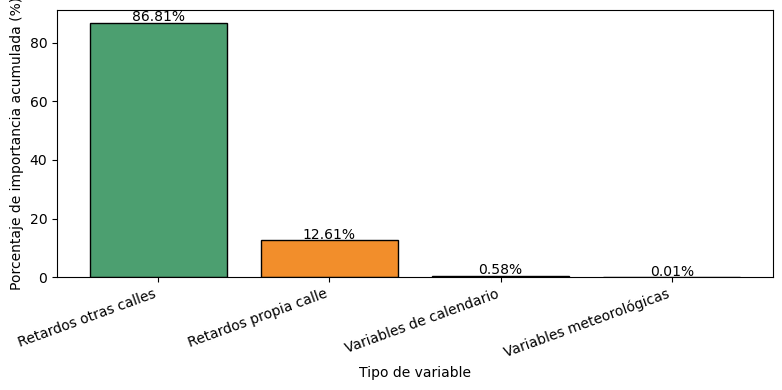

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.bar(resumen_tipos["tipo_variable"], resumen_tipos["porcentaje"],
        color=['#4C9F70', '#F28E2B', '#8E63CE', '#BDBDBD'],
        edgecolor='black')

plt.ylabel("Porcentaje de importancia acumulada (%)")
plt.xlabel("Tipo de variable")

for i, v in enumerate(resumen_tipos["porcentaje"]):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center')

plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()